---
title: "Reglas de Asociación"
format:
  html:
    code-fold: false
---

In [2]:
#| echo: false
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import association_rules

df = pd.read_parquet('../data/logs.parquet')

Las reglas de asociación son una técnica de data mining que se utiliza para descubrir
patrones entre variables en conjuntos de datos muy grandes. En este caso, se va a aplicar para
descubrir cuáles son las piezas que se añaden a un diseño juntas. Estas reglas se expresan como
{A} → {B}, por ejemplo: “Si un usuario añade una pieza A, entonces también añade la pieza
B”. El objetivo es extraer patrones para poder hacer recomendaciones personalizadas.

## Filtrado y exploracion de los datos

Antes de generar las reglas de asociación, tenemos que transformar los datos a un formato correcto. Los datos tienen que estar en formato transaccional, donde cada registro, los
diseños, sea una lista de ítems, en nuestro caso de piezas.

Para aplicar el algoritmo, es suficiente extraer las columnas pieza y diseñoid del conjunto
original, y filtrar por los diseños válidos y el catálogo estándar

In [3]:
añadir_fabricante = df[(df['Evento'] == 'AÑADIR_PIEZA') & (df['catalogo'] == 'Estandar') & (df['diseñoid'] != '-1') & (df['diseñoid'] != '0')].copy()
añadir_fabricante = añadir_fabricante[['pieza', 'diseñoid']]

print(f"Número total de diseños: {añadir_fabricante['diseñoid'].nunique()}")
print(f"Número total de ítems diferentes (piezas): {añadir_fabricante['pieza'].nunique()}")
print(f"Número total de ítems (piezas): {añadir_fabricante['pieza'].count()}")

Número total de diseños: 20898
Número total de ítems diferentes (piezas): 320
Número total de ítems (piezas): 154563


In [4]:
añadir_fabricante.tail(10)

,pieza,diseñoid
2008476,ED-PLA-12,82459
2008489,ED-COR-03,82459
2008502,ED-ALF-04,82459
2008515,ED-LIB-11,82459
2008526,SILLON_02,82436
2008532,ED-PLA-02,82436
2008545,EE-VBA-03,82327
2008556,EE-PCR-01,82327
2008560,EE-PCI-06,82300
2008564,EE-VBA-03,82300


## Observación del tamaño de las transacciones

count    20898.000000
mean         7.396067
std          9.656771
min          1.000000
25%          2.000000
50%          4.000000
75%          9.000000
90%         17.000000
max        285.000000
Name: pieza, dtype: float64


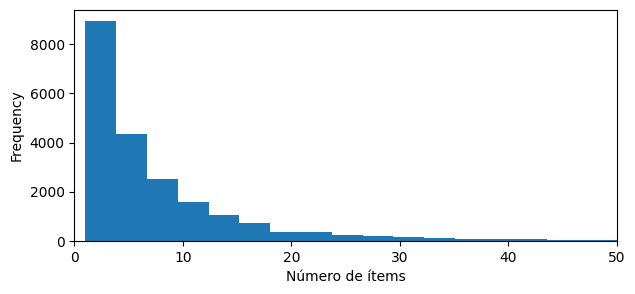

In [5]:
print(añadir_fabricante.groupby('diseñoid')['pieza'].size().describe(percentiles=[.25, .5, .75, .9]))
fig, ax = plt.subplots(figsize=(7, 3))
añadir_fabricante.groupby('diseñoid')['pieza'].size().plot.hist(ax=ax, bins=100)
ax.set_xlim(0, 50) 
ax.set_xlabel('Número de ítems')
plt.show()

## Transformacion del dataframe en transacciones

In [6]:
transacciones = añadir_fabricante.groupby('diseñoid')['pieza'].apply(list).to_list()
te = TransactionEncoder()
te_ary = te.fit(transacciones).transform(transacciones)
df_transacciones = pd.DataFrame(te_ary, columns=te.columns_)
df_transacciones.head(5)

,BALÓN,BN-BDS-01,BN-BDS-02,BN-BDS-03,BN-BDS-04,BN-BNR-01,BN-BNR-02,BN-BNR-03,BN-BNR-04,BN-BNR-05,...,SOF-011,SOF-013,SOF-014,SOF-015,SOF-016,SOF-017,SOF-021,SOF-022,SOF-023,SOF-024
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False


## Aplicación del algoritmo apriori

El algoritmo Apriori sirve para identificar los patrones más frecuentes para, posteriormente, generar las reglas de asociación. Es decir, el algoritmo tiene dos fases: primero identificamos el conjunto de ítems frecuentes con la función apriori de mlxtend con un soporte mínimo,
min_support, de 0.001, y a partir de este conjunto de ítems generamos las reglas de asociación con association_rules que satisfagan un umbral mínimo de confianza, en este caso con un
min_threshold de 0.5.

- **Soporte:** El soporte mide la proporción de veces que aparece un conjuntos de ítems en una transacción sobre el total de transacciones:
    $$
    support(A) = \frac{Numero\ de\ transacciones\ que\ contienen \ A}{Numero\ total\ transacciones}
    $$
        
- **Confianza:** La confianza mide la probabilidad de que ocurra B dado que ha ocurrido A:
    $$
    confidence(A \rightarrow B) = \frac{support(A \cup B)}{support(A)}
    $$

- **Lift:** El *lift* mide si la presencia de A aumenta la probabilidad de que ocurra B, en comparación de que ocurra B solo:
    $$
        lift(A \rightarrow B) = \frac{support(A \cup B)}{support(A)\cdot support(B)}
    $$


In [25]:
itemsets = apriori(df_transacciones, min_support=0.001, use_colnames=True)

Ordeno los itemsets por frecuencia de manera descendente

In [26]:
itemsets['n_items'] = itemsets['itemsets'].apply(len)
itemsets.sort_values(by='support', ascending=True).head(10)

,support,itemsets,n_items
17637,0.001005,"(ED-BAN-01, CU_VA_02, ED-ALF-02, ED-TVT-01)",4
11239,0.001005,"(ED-JAR-32, ED-COR-03, ED-JAR-22)",3
3040,0.001005,"(ED-PPC-02, ED-EST-03)",2
17798,0.001005,"(ED-PLA-02, EE-PILAR-01, ED-ALF-02, ED-BAN-01)",4
17795,0.001005,"(ED-BAN-01, ED-LPR-02, ED-ALF-02, EE-PILAR-01)",4
11241,0.001005,"(ED-JAR-22, ED-COR-03, ED-PLA-01)",3
17771,0.001005,"(ED-JAR-32, ED-TVT-02, ED-ALF-02, ED-BAN-01)",4
7966,0.001005,"(EE-RAD-01, ED-ALF-01, EE-PILAR-01)",3
17756,0.001005,"(ED-JAR-32, ED-JAR-02, ED-ALF-02, ED-BAN-01)",4
7985,0.001005,"(ED-LPR-13, ED-ALF-03, ED-ALF-02)",3


### Generación de las Reglas de Asociación

In [27]:
reglas = association_rules(itemsets, metric="confidence", min_threshold=0.5)
columnas = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
reglas = reglas[columnas]
reglas.tail(10)


,antecedents,consequents,support,confidence,lift
7086,"(SGE-001, EE-VBA-03, ED-PPC-01, EE-PILAR-01, E...",(ED-EST-01),0.001244,0.787879,6.095924
7087,"(SGE-001, ED-EST-01, ED-PPC-01, EE-PILAR-01, E...",(EE-VBA-03),0.001244,0.530612,6.289696
7088,"(EE-VBA-03, ED-EST-01, ED-PPC-01, EE-PILAR-01,...",(SGE-001),0.001244,0.509804,3.755334
7089,"(SGE-004, EE-VBA-03, ED-EST-01, ED-PPC-01, EE-...",(EE-RAD-01),0.001148,0.750000,4.821132
7090,"(SGE-004, EE-VBA-03, ED-EST-01, ED-PPC-01, EE-...",(EE-PILAR-01),0.001148,0.533333,2.390734
7091,"(SGE-004, EE-VBA-03, ED-EST-01, EE-PILAR-01, E...",(ED-PPC-01),0.001148,0.727273,7.915909
7092,"(SGE-004, EE-VBA-03, ED-PPC-01, EE-PILAR-01, E...",(ED-EST-01),0.001148,0.888889,6.877453
7093,"(SGE-004, EE-VBA-03, ED-EST-01, EE-PILAR-01)","(EE-RAD-01, ED-PPC-01)",0.001148,0.521739,21.379028
7094,"(SGE-004, EE-VBA-03, ED-PPC-01, EE-PILAR-01)","(EE-RAD-01, ED-EST-01)",0.001148,0.615385,15.995408
7095,"(SGE-004, EE-VBA-03, EE-RAD-01, EE-PILAR-01)","(ED-EST-01, ED-PPC-01)",0.001148,0.500000,15.879939


### Filtrado de reglas

In [20]:
reglas_conf = reglas[reglas['confidence'] > 0.9]
reglas_conf.head(10)

,antecedents,consequents,support,confidence,lift
369,"(SGE-004, ED-PPC-06)",(ED-PPC-01),0.002010,0.954545,10.389631
556,"(SGE-004, EE-VBA-03, ED-ALF-02)",(ED-EST-01),0.002058,0.914894,7.078655
778,"(SGE-004, ED-LPR-13, ED-LIB-14)",(ED-PPC-01),0.002775,0.920635,10.020536
783,"(SGE-004, EE-RAD-01, ED-LIB-14)",(ED-PPC-01),0.002201,0.920000,10.013625
869,"(SGE-004, ED-LPR-13, EE-RAD-01, ED-EST-01)",(ED-PPC-01),0.002536,0.913793,9.946067


In [21]:
reglas_antecentes = reglas[reglas['antecedents'].apply(lambda x: len(x) > 1)]
reglas_antecentes.head(10)

,antecedents,consequents,support,confidence,lift
14,"(CAM-02, ED-LIB-11)",(ED-LPR-02),0.002393,0.724638,9.707358
15,"(ED-PPC-01, CU_CI_01)",(SGE-001),0.002536,0.569892,4.197960
16,"(SGE-001, CU_CI_01)",(ED-PPC-01),0.002536,0.524752,5.711603
17,"(CU_CI_04, SOF-022)",(ED-TVT-01),0.002105,0.550000,5.729761
18,"(ED-BAN-01, CU_CI_05)",(ED-LPR-01),0.002105,0.602740,12.276857
19,"(CU_IN_02, ED-PPC-01)",(SGE-001),0.003685,0.534722,3.938888
20,"(CU_IN_02, SGE-001)",(ED-PPC-01),0.003685,0.516779,5.624811
21,"(CU_IN_02, EE-PILAR-01)",(SGE-001),0.002536,0.504762,3.718193
22,"(CU_IN_02, EE-VCR-01)",(SGE-001),0.002967,0.521008,3.837869
23,"(ED-PPC-01, CU_IN_03)",(SGE-001),0.002823,0.508621,3.746618


In [35]:
print(len(reglas))
reglas.sort_values(by = 'support', ascending = True).head(10)

7096


,antecedents,consequents,support,confidence,lift
2757,"(ED-JAR-12, ED-LIB-11, ED-TVT-01)",(ED-ALF-02),0.001005,0.525000,4.226290
3998,"(EE-VBA-03, EE-RAD-01, ED-BAN-02)",(ED-JAR-02),0.001005,0.512195,13.430180
5903,"(ED-LPR-01, ED-BAN-02, ED-ALF-02, EE-PILAR-01)",(ED-TVT-01),0.001005,0.777778,8.102692
3999,"(EE-VBA-03, ED-JAR-02, ED-BAN-02)",(EE-RAD-01),0.001005,0.567568,3.648424
5902,"(ED-BAN-02, EE-PILAR-01, ED-ALF-02, ED-TVT-01)",(ED-LPR-01),0.001005,0.567568,11.560455
5901,"(ED-BAN-02, ED-LPR-01, EE-PILAR-01, ED-TVT-01)",(ED-ALF-02),0.001005,0.567568,4.568963
4000,"(ED-JAR-12, ED-LPR-01, ED-BAN-02)",(ED-TVT-01),0.001005,0.636364,6.629475
1920,"(EE-PCI-01, ED-EST-01, CAM-02)",(ED-LPR-02),0.001005,0.617647,8.274095
1919,"(EE-PCI-01, ED-LPR-02, CAM-02)",(ED-EST-01),0.001005,0.512195,3.962922
4001,"(ED-JAR-32, ED-BAN-02, ED-LIB-12)",(ED-TVT-01),0.001005,0.552632,5.757176


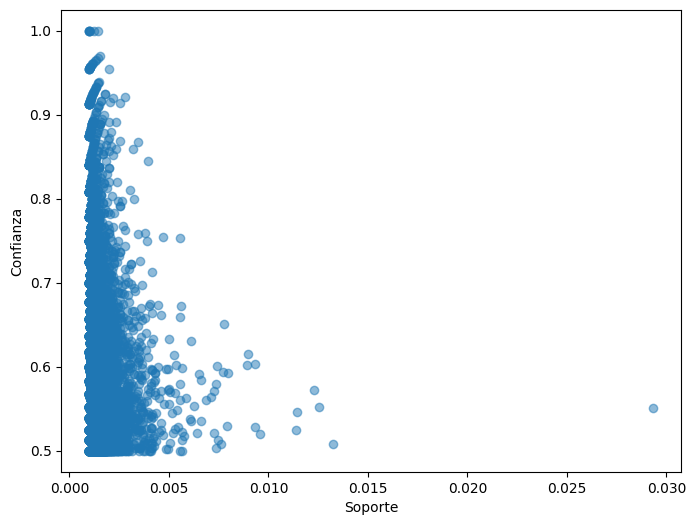

In [33]:
plt.figure(figsize=(8, 6))
plt.scatter(reglas['support'], reglas['confidence'], alpha=0.5)

plt.xlabel('Soporte')
plt.ylabel('Confianza')
plt.show()

In [37]:
# Visualizar soporte vs lift o confianza vs lift
print(reglas.nunique())

antecedents    4304
consequents     117
support         120
confidence      875
lift           3943
dtype: int64


Las mejores reglas se encuentran cuando la confianza es mayor a 0.7, indica que, en la
mayoría de los casos, cuando aparece el consecuente, también aparece el antecedente. Esto
da lugar a reglas más fiables. Por otro lado, las reglas más hacia la derecha indican un mayor
soporte, es decir, estas reglas aparecen en más transacciones.

## Recomendador de piezas

Se ha implementado un algoritmo recomendador de piezas del catálogo estándar basado en las reglas de asociación. El algoritmo acepta una lista de una o más piezas y, en función
de esas piezas, devuelve las N piezas más relevantes.

In [15]:
def recomendar_pieza(piezas_usuario, reglas, top_n=5):
    reglas_validas = reglas[reglas['antecedents'].apply(lambda x: piezas_usuario.issubset(x))]
    reglas_validas = reglas_validas.sort_values(['confidence', 'lift'], ascending=False)
    piezas_recomendadas = []
    for consequents in reglas_validas['consequents']:
        for pieza in consequents:
            if pieza not in piezas_usuario and pieza not in piezas_recomendadas:
                piezas_recomendadas.append(pieza)
                if len(piezas_recomendadas) >= top_n:
                    return piezas_recomendadas
    return piezas_recomendadas

In [39]:
piezas_usuario = {'ED-LIB-12', 'ED-TVT-01'}
recomendaciones = recomendar_pieza(piezas_usuario, reglas, top_n=5)
print("Piezas recomendadas:", recomendaciones)

Piezas recomendadas: ['ED-JAR-32', 'SOF-022', 'ED-ALF-03', 'ED-LPR-01', 'ED-BAN-01']
